# Phase 3
## 1. Khách hàng có thật sự "trung thành" như Phase 2 cho thấy không?

Phase 2 đưa ra 1 con số rất tích cực: **91.5% khách hàng đã mua lại ít nhất 2 lần** (mục 2.2). Đây là con số báo cáo "retention tốt". Nhưng con số này được tính bằng cách đếm **số đơn hàng (Transaction_ID)** — nó không cho biết khách hàng có thực sự **quay lại nhiều lần khác nhau trong năm**, hay chỉ đặt nhiều đơn dồn vào 1-2 lần ghé mua kề nhau.

Phase 3 sẽ kiểm tra lại con số này bằng kỹ thuật **RFM (Recency, Frequency, Monetary)** — nhưng trước khi tính, cần đảm bảo đơn vị "1 đơn hàng" trong dữ liệu là đáng tin cậy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fact_sales = pd.read_csv('data/processed/fact_sales.csv')
dim_customer = pd.read_csv('data/processed/dim_customer.csv')
fact_sales['Transaction_Date'] = pd.to_datetime(fact_sales['Transaction_Date'])

fact_sales.head(3)

,Transaction_ID,CustomerID,Transaction_Date,Year,Quarter,Month,Week,DayOfWeek,Product_SKU,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Discount_pct,Invoice_Value
0,16679,17850,2019-01-01,2019,1,Jan,1,Tuesday,GGOENEBJ079499,1,153.71,6.5,Used,0.1,158.67
1,16680,17850,2019-01-01,2019,1,Jan,1,Tuesday,GGOENEBJ079499,1,153.71,6.5,Used,0.1,158.67
2,16681,17850,2019-01-01,2019,1,Jan,1,Tuesday,GGOEGFKQ020399,1,2.05,6.5,Used,0.1,8.53


---
### 1.1 Kiểm tra tính hợp lệ của Transaction_ID trước khi tính RFM

RFM cần đếm "số đơn hàng" của mỗi khách (`Frequency`). Vì vậy, trước tiên cần chắc chắn: **1 Transaction_ID luôn thuộc về đúng 1 khách hàng duy nhất**. Nếu không, việc đếm Frequency theo Transaction_ID sẽ sai.

In [2]:
# Với mỗi Transaction_ID, đếm xem có bao nhiêu CustomerID khác nhau xuất hiện
check = fact_sales.groupby('Transaction_ID')['CustomerID'].nunique()

# Nếu hợp lệ, check phải luôn luôn = 1 (1 đơn hàng chỉ thuộc 1 khách)
loi = check[check > 1]

print(f"Tổng số Transaction_ID cũ: {check.shape[0]}")
print(f"Số Transaction_ID gắn với NHIỀU HƠN 1 khách hàng: {loi.shape[0]} ({loi.shape[0]/check.shape[0]*100:.1f}%)")

Tổng số Transaction_ID cũ: 25061
Số Transaction_ID gắn với NHIỀU HƠN 1 khách hàng: 1319 (5.3%)


> **Phát hiện:** 5.3% Transaction_ID (1319 mã) đang sai nguyên tắc cơ bản là 1 mã đơn hàng lại gắn với hơn 1 CustomerID khác nhau.

In [3]:
# Xem chi tiết 1 Transaction_ID bị lỗi
vi_du = fact_sales[fact_sales['Transaction_ID'] == 16682]
vi_du[['Transaction_ID', 'CustomerID', 'Product_SKU', 'Quantity', 'Avg_Price']]

,Transaction_ID,CustomerID,Product_SKU,Quantity,Avg_Price
3,16682,17850,GGOEGAAB010516,5,17.53
4,16682,17850,GGOEGBJL013999,1,16.50
5,16682,17850,GGOEGBMJ013399,15,5.15
6,16682,17850,GGOEGDHC018299,15,3.08
7,16682,17850,GGOEGDHG014499,15,10.31
8,16682,17850,GGOEGDWC020199,5,9.27
9,16682,13047,GGOEGGOA017399,52,0.98
10,16682,13047,GGOEGOFH020299,31,1.99
11,16682,13047,GGOEGOXQ016399,31,1.99
12,16682,13047,GGOEYAAB031816,5,17.53


> **Phát hiện:** Transaction_ID 16682 có 6 dòng sản phẩm của khách 17850 và 4 dòng của khách 13047 — rõ ràng đây là **2 đơn hàng khác nhau bị gộp nhầm vào cùng 1 mã**. Đây là lỗi có sẵn trong dữ liệu gốc (Kaggle), không phải lỗi do Phase 1 xử lý gây ra, vì `Transaction_ID` không bị biến đổi qua bất kỳ phép tính nào.
>
> **Xử lý:** Không xoá các dòng này vì chiếm tới 14.7% dữ liệu. Thay vào đó, sửa lại **định nghĩa 1 đơn hàng**: dùng tổ hợp **(Transaction_ID, CustomerID)** làm khoá, vì nếu 2 khách khác nhau cùng xuất hiện trong 1 Transaction_ID, thì nó sẽ tạo nên 2 đơn hàng riêng biệt dù bị gán nhầm chung mã. Cách này giữ nguyên 100% doanh thu, giúp cho việc đếm "số đơn hàng" chính xác hơn.

In [4]:
# Gộp fact_sales (line-item) về mức ĐƠN HÀNG, dùng khoá (Transaction_ID, CustomerID) đã sửa
orders = fact_sales.groupby(['Transaction_ID', 'CustomerID']).agg(
    Order_Date=('Transaction_Date', 'first')
    ,Order_Revenue=('Invoice_Value', 'sum')
).reset_index()

print(f"Số đơn hàng TRƯỚC khi sửa (chỉ group theo Transaction_ID): 25061")
print(f"Số đơn hàng SAU khi sửa (group theo Transaction_ID + CustomerID): {orders.shape[0]}")
print(f"Chênh lệch: {orders.shape[0] - 25061} đơn hàng đã bị gộp nhầm trước đây")
display(orders)

Số đơn hàng TRƯỚC khi sửa (chỉ group theo Transaction_ID): 25061
Số đơn hàng SAU khi sửa (group theo Transaction_ID + CustomerID): 26631
Chênh lệch: 1570 đơn hàng đã bị gộp nhầm trước đây


,Transaction_ID,CustomerID,Order_Date,Order_Revenue
0,16679,17850,2019-01-01,158.67
1,16680,17850,2019-01-01,158.67
2,16681,17850,2019-01-01,8.53
3,16682,13047,2019-01-01,305.25
4,16682,17850,2019-01-01,528.22
...,...,...,...,...
26626,48493,14410,2019-12-31,139.93
26627,48494,14410,2019-12-31,46.91
26628,48495,14410,2019-12-31,123.45
26629,48496,14600,2019-12-31,449.36


---
### 1.2 Tính RFM — Frequency đo bằng số NGÀY khác nhau, không đếm theo đơn hàng

>RFM: Recency (số ngày từ lần mua cuối), Frequency (tần suất mua hàng), Monetary (tổng tiền).
>
>Đây là điểm khác với cách tính RFM thường gặp: thay vì `Frequency = số đơn hàng` được dùng ở phase 2 thì ta dùng `Frequency = số ngày khác nhau khách có mua hàng` **để xem xét rõ con số 91.5% khách hàng mua > 1 lần có hợp lí không**.

In [5]:
# Lấy ngày mua gần nhất trong dữ liệu, cộng thêm 1 ngày để làm mốc tính Recency
snapshot_date = orders['Order_Date'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('CustomerID').agg(
    Last_Purchase=('Order_Date', 'max'),
    Frequency=('Order_Date', 'nunique'),   # đếm số NGÀY KHÁC NHAU
    Monetary=('Order_Revenue', 'sum')
).reset_index()

# Recency = ngày mốc trừ ngày mua gần nhất của khách hàng
rfm['Recency'] = (snapshot_date - rfm['Last_Purchase']).dt.days

print(f"Số khách hàng: {rfm.shape[0]}")
display(rfm.head(5))
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(1)

Số khách hàng: 1468


,CustomerID,Last_Purchase,Frequency,Monetary,Recency
0,12346,2019-09-15,1,174.98,108
1,12347,2019-11-02,3,15686.83,60
2,12348,2019-10-19,2,1689.54,74
3,12350,2019-12-14,1,1467.45,18
4,12356,2019-09-15,1,2007.39,108


,Recency,Frequency,Monetary
count,1468.0,1468.0,1468.0
mean,145.3,2.2,3676.7
std,101.9,2.2,5846.1
min,1.0,1.0,7.0
25%,56.0,1.0,784.0
50%,132.0,1.5,2011.6
75%,221.0,3.0,4495.1
max,365.0,34.0,87201.0


In [6]:
# Kiểm tra 1 khách có nhiều Transaction_ID, để xem họ thực sự mua trải dài không
khach_kiem_tra = 17337

vi_du2 = fact_sales[fact_sales['CustomerID'] == khach_kiem_tra]
print(f"Khách hàng {khach_kiem_tra}:")
print(f"  Số Transaction_ID khác nhau: {vi_du2['Transaction_ID'].nunique()}")
print(f"  Số NGÀY khác nhau có mua hàng: {vi_du2['Transaction_Date'].nunique()}")
print(f"  Các ngày mua: {sorted(vi_du2['Transaction_Date'].dt.strftime('%d-%m-%Y').unique())}")

Khách hàng 17337:
  Số Transaction_ID khác nhau: 139
  Số NGÀY khác nhau có mua hàng: 2
  Các ngày mua: ['14-12-2019', '15-12-2019']


> **Phát hiện:** Khách hàng này đặt **139 đơn hàng riêng biệt** nhưng chỉ trong **2 ngày liên tiếp** (14-15/12/2019). Nếu tính Frequency theo số đơn hàng, khách này sẽ là một trong những khách "trung thành nhất" của cả năm — nhưng thực chất họ chỉ ghé mua đúng 1 lần (kéo dài 2 ngày), giống hành vi mua sỉ hoặc đặt hàng theo lô hơn là khách quay lại nhiều lần.

In [7]:
# Kiểm tra xem đây là cá biệt hay phổ biến: so sánh Active_Days trung bình của nhóm Frequency cao nhất
# tạo thêm 1 cột tổng số đơn hàng theo CustomerID
# để kiểm tra xem có phải hầu hết khách hàng đều đặt nhiều đơn chỉ trong 1-2 ngày như trường hợp bên trên không.
so_don_theo_khach = fact_sales.groupby('CustomerID')['Transaction_ID'].nunique().reset_index(name='So_Don')
kt = rfm.merge(so_don_theo_khach, on='CustomerID')

# lấy ra top 25% trong số customerID có nhiều transactionID nhất
nguong_cao = kt['So_Don'].quantile(0.75)
nhom_don_cao = kt[kt['So_Don'] >= nguong_cao]

print(f"Nhóm có SỐ ĐƠN HÀNG cao (top 25%, từ {nguong_cao:.0f} đơn trở lên): {nhom_don_cao.shape[0]} khách")
print(f"  Số NGÀY quay lại trung bình (Frequency) của nhóm này: {nhom_don_cao['Frequency'].mean():.1f} ngày")
print(f"  Trung bình số đơn/ngày hoạt động: {(nhom_don_cao['So_Don']/nhom_don_cao['Frequency']).mean():.1f} đơn/ngày")

Nhóm có SỐ ĐƠN HÀNG cao (top 25%, từ 23 đơn trở lên): 387 khách
  Số NGÀY quay lại trung bình (Frequency) của nhóm này: 3.8 ngày
  Trung bình số đơn/ngày hoạt động: 15.9 đơn/ngày


> **Kết luận:** Khách hàng có ID: 17337 không phải trường hợp đặt biệt mà nhóm khách đặt nhiều đơn hàng nhất (top 25% theo số đơn) cũng chỉ quay lại trung bình **3.8 ngày khác nhau/năm** và đặt trung bình tới **15.9 đơn/ngày hoạt động**. Nên Nếu tính "khách trung thành" theo số đơn hàng, phần lớn nhóm này thực chất chỉ mua dồn dập trong vài ngày, không quay lại đều đặn suốt năm như tên gọi "trung thành" với con số 91.5%.
>
> Đây là lý do `Frequency` trong RFM ở Phase 3 được tính bằng **số ngày khác nhau** — để kiểm tra đúng là "khách có thực sự quay lại nhiều lần hay không", không bị nhiễu bởi việc đặt nhiều đơn nhỏ trong 1 lần ghé mua.

---
### 1.3 Vậy thực tế: bao nhiêu % khách hàng thực sự đã "quay lại"?

Quay lại câu hỏi gốc ở đầu notebook: Phase 2 nói 91.5% khách "đã mua lại" (tính theo đơn hàng). Giờ kiểm tra lại bằng Frequency mới (số ngày khác nhau).

In [8]:
so_khach_1_ngay = (rfm['Frequency'] == 1).sum()
ty_le_1_ngay = so_khach_1_ngay / rfm.shape[0] * 100

print(f"Số khách chỉ mua hàng trong DUY NHẤT 1 ngày suốt cả năm: {so_khach_1_ngay:,} / {rfm.shape[0]:,} ({ty_le_1_ngay:.1f}%)")

Số khách chỉ mua hàng trong DUY NHẤT 1 ngày suốt cả năm: 734 / 1,468 (50.0%)


> **Đây là phát hiện quan trọng nhất của Phase 3:** Có tới **50% khách hàng (734 người) chỉ mua hàng trong 1 ngày duy nhất** suốt cả năm 2019 mặc dù họ có thể đặt nhiều đơn hàng trong ngày đó. Con số này **khác hẳn** với "91.5% đã mua lại" ở Phase 2, vì Phase 2 đếm theo số đơn hàng (bị thổi phồng bởi việc đặt nhiều đơn trong cùng 1 lần ghé), còn ở đây đếm theo số ngày quay lại thực tế.
>
> Nói cách khác: rất nhiều khách hàng "đã mua lại" theo Phase 2 thực chất là đặt **nhiều đơn trong cùng 1 lần ghé mua**, không phải quay lại vào 1 dịp khác.

In [9]:
# Phân nhóm khách hàng theo Frequency (số ngày quay lại) để xem giá trị từng nhóm
def nhom_theo_frequency(so_ngay):
    if so_ngay == 1:
        return 'mua 1 lần (không quay lại)'
    elif so_ngay <= 3:
        return 'quay lại 2-3 lần'
    elif so_ngay <= 7:
        return 'quay lại 4-7 lần'
    else:
        return 'quay lại từ 8 lần (khách lõi)'

rfm['Nhom_Khach'] = rfm['Frequency'].apply(nhom_theo_frequency)

segment_summary = rfm.groupby('Nhom_Khach').agg(
    Customer=('CustomerID', 'count')
    ,Monetary_TB=('Monetary', 'mean')
    ,Tong_Revenue=('Monetary', 'sum')
    ).round(1)
segment_summary['Pct_Customer(%)'] = (segment_summary['Customer'] / segment_summary['Customer'].sum() * 100).round(1)
segment_summary['Pct_Revenue(%)'] = (segment_summary['Tong_Revenue'] / segment_summary['Tong_Revenue'].sum() * 100).round(1)

display(segment_summary)

,Customer,Monetary_TB,Tong_Revenue,Pct_Customer(%),Pct_Revenue(%)
Nhom_Khach,,,,,
mua 1 lần (không quay lại),734,1736.4,1274485.5,50.0,23.6
quay lại 2-3 lần,525,3930.2,2063363.0,35.8,38.2
quay lại 4-7 lần,179,7655.7,1370374.8,12.2,25.4
quay lại từ 8 lần (khách lõi),30,22971.4,689141.8,2.0,12.8


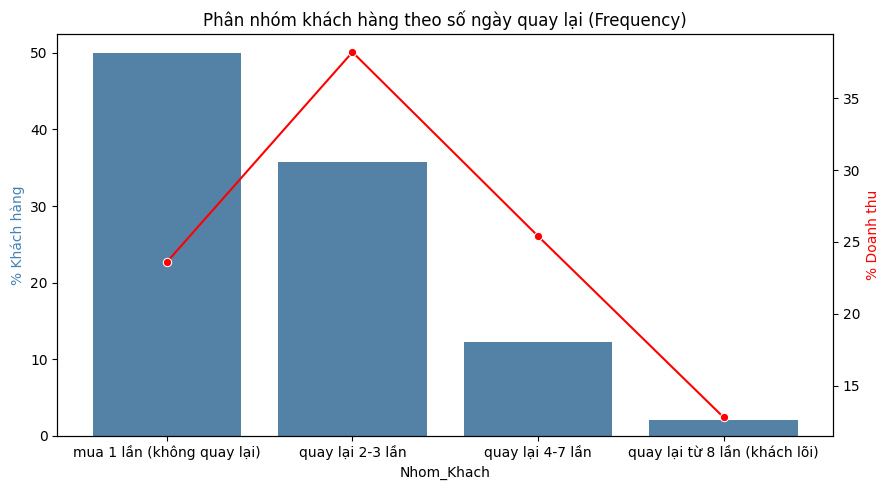

In [10]:
fig, ax1 = plt.subplots(figsize=(9, 5))

x = segment_summary.index
sns.barplot(x=x, y=segment_summary['Pct_Customer(%)'], color='steelblue', ax=ax1)
ax1.set_ylabel('% Khách hàng', color='steelblue')

ax2 = ax1.twinx()
sns.lineplot(x=x, y=segment_summary['Pct_Revenue(%)'], marker='o', color='red', ax=ax2)
ax2.set_ylabel('% Doanh thu', color='red')

plt.title('Phân nhóm khách hàng theo số ngày quay lại (Frequency)')
plt.tight_layout()
plt.show()

> **Insight:** Nhóm **"khách lõi" (quay lại từ 8 ngày khác nhau trở lên) chỉ chiếm 2.0% khách hàng (30 người) nhưng đóng góp 12.8% doanh thu**, với Monetary trung bình **22,971/khách — gấp 13 lần** nhóm "chỉ mua 1 ngày" (1,736/khách). Đây là nhóm khách hàng giá trị thật, được xác định bằng hành vi quay lại thực tế.
>
> Ngược lại, nhóm "chỉ mua 1 ngày" chiếm tới 50% khách hàng nhưng chỉ đóng góp 23.6% doanh thu — đây là nhóm rủi ro nhất vì có thể sẽ không còn quay lại nữa.

---
### 1.4 Kiểm tra lại: 50% khách "chỉ mua 1 ngày" có phải do chưa đủ thời gian để quay lại hay không?

Một câu hỏi cần đặt ra trước khi kết luận: khách mua vào tháng 11-12 chỉ còn rất ít thời gian trong năm để quay lại — liệu con số 50% có bị thổi phồng vì nhiều khách trong nhóm này đơn giản là chưa có đủ thời gian, không phải vì họ thực sự không quay lại?

Để kiểm tra công bằng: chỉ xét khách có R(Recency) **ít nhất 60 ngày** kể từ lần mua đầu tiên đến hết năm.

In [11]:
# Lấy nhóm khách chỉ mua 1 ngày duy nhất (Frequency = 1, đã tìm ở Mục 3)
# Recency <= 60: mua gần cuối năm -> chưa đủ thời gian quan sát để kết luận
# Recency > 60: mua từ lâu mà vẫn không quay lại -> tín hiệu đáng tin về việc không trung thành
khach_1_ngay = rfm[rfm['Frequency'] == 1]
chua_du_thoi_gian = khach_1_ngay[khach_1_ngay['Recency'] <= 60]
khong_quay_lai = khach_1_ngay[khach_1_ngay['Recency'] > 60]

tong = khach_1_ngay.shape[0]
print(f"Tổng số khách chỉ mua 1 ngày: {tong}")
print(f" Khách hàng chưa đủ thời gian quay lại (Recency <= 60): {chua_du_thoi_gian.shape[0]} khách ({chua_du_thoi_gian.shape[0]/tong*100:.1f}%)")
print(f" Khách hàng sẽ không quay lại (Recency > 60): {khong_quay_lai.shape[0]} khách ({khong_quay_lai.shape[0]/tong*100:.1f}%)")

Tổng số khách chỉ mua 1 ngày: 734
 Khách hàng chưa đủ thời gian quay lại (Recency <= 60): 134 khách (18.3%)
 Khách hàng sẽ không quay lại (Recency > 60): 600 khách (81.7%)


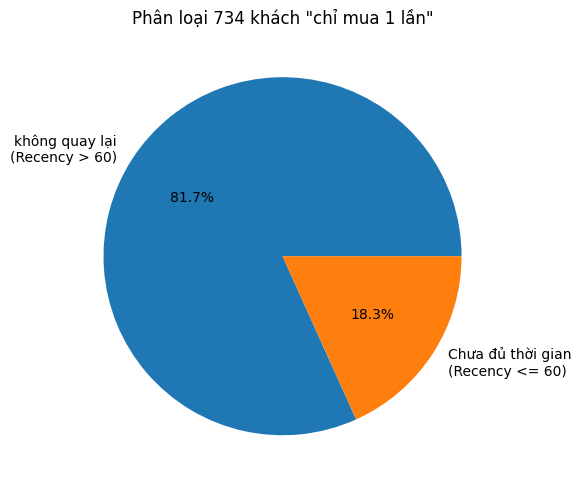

In [12]:
plt.figure(figsize=(6, 5))
plt.pie(
    [khong_quay_lai.shape[0], chua_du_thoi_gian.shape[0]]
    ,labels=['không quay lại\n(Recency > 60)', 'Chưa đủ thời gian\n(Recency <= 60)']
    ,autopct='%1.1f%%')
plt.title('Phân loại 734 khách "chỉ mua 1 lần"')
plt.tight_layout()
plt.show()

> **Kết luận kiểm định:** Trong 734 khách "chỉ mua 1 ngày", chỉ có **18.3% (134 khách)** mua gần cuối năm nên có thể chưa kịp quay lại — phần còn lại, **81.7% (600 khách), đã mua từ lâu (hơn 60 ngày trước khi kết thúc năm) mà vẫn không quay lại**. Đây là tín hiệu đáng tin, không phải do thiếu thời gian quan sát.
>
> Vậy con số 50% khách "chỉ mua 1 ngày" ở Mục 3 **không bị thổi phồng đáng kể** — phần lớn (600/1,468 = 40.9% tổng khách hàng) là vấn đề retention thật, cần được ưu tiên xử lý, không thể giải thích bằng lý do "chưa kịp quay lại".

---
## 2. ROAS ổn định ở Phase 2 — nhưng có đang thu hút khách mới hiệu quả không?

Phase 2 cho thấy ROAS dao động 2.69x-3.76x theo tháng, không có xu hướng rõ ràng, và tháng có doanh thu cao nhất (Dec) lại không có ROAS cao nhất. Nhưng ROAS đo trên **tổng doanh thu** (cả khách cũ và khách mới cộng lại) — nó không cho biết tiền marketing có đang **thu hút thêm khách hàng mới** hay chỉ khiến khách cũ mua nhiều hơn. Đây là câu hỏi quan trọng với bối cảnh công ty muốn biết nên tập trung ngân sách vào đâu để tăng trưởng tệp khách hàng, không chỉ tăng doanh thu ngắn hạn.

In [13]:
# Đếm số khách hàng MỚI (lần đầu mua hàng) theo từng tháng
first_purchase = orders.groupby('CustomerID')['Order_Date'].min().reset_index()
first_purchase.columns = ['CustomerID', 'First_Purchase_Date']
first_purchase['Month'] = first_purchase['First_Purchase_Date'].dt.strftime('%b')
khach_moi_theo_thang = first_purchase.groupby('Month')['CustomerID'].count().reset_index(name='Khach_Moi')

# Tổng Marketing Spend theo từng tháng (từ dim_marketing)
dim_marketing = pd.read_csv('data/processed/dim_marketing.csv')
dim_marketing['Date'] = pd.to_datetime(dim_marketing['Date'])
dim_marketing['Month'] = dim_marketing['Date'].dt.strftime('%b')
spend_theo_thang = dim_marketing.groupby('Month')['Total_Spend'].sum().reset_index()

# Gộp lại và tính chi phí trung bình để có 1 khách hàng MỚI trong tháng đó
mkt_vs_new = khach_moi_theo_thang.merge(spend_theo_thang, on='Month')
mkt_vs_new['Cost_per_New_Customer'] = (mkt_vs_new['Total_Spend'] / mkt_vs_new['Khach_Moi']).round(0)

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mkt_vs_new['Month'] = pd.Categorical(mkt_vs_new['Month'], categories=month_order, ordered=True)
mkt_vs_new = mkt_vs_new.sort_values('Month').reset_index(drop=True)

mkt_vs_new

,Month,Khach_Moi,Total_Spend,Cost_per_New_Customer
0,Jan,215,154928.95,721.0
1,Feb,96,137107.92,1428.0
2,Mar,177,122250.09,691.0
3,Apr,163,157026.83,963.0
4,May,112,118259.64,1056.0
5,Jun,137,134318.14,980.0
6,Jul,94,120217.85,1279.0
7,Aug,135,142904.15,1059.0
8,Sep,78,135514.54,1737.0
9,Oct,87,151224.65,1738.0


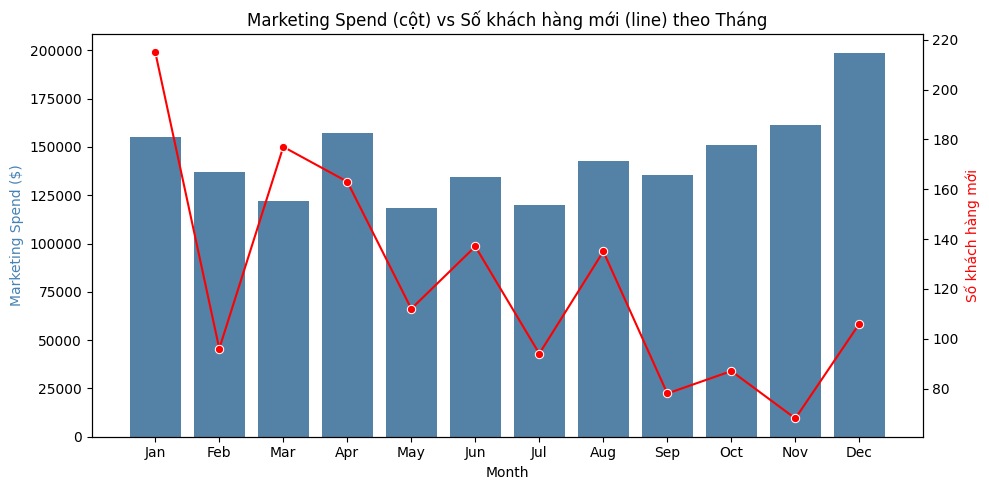

Hệ số tương quan giữa Marketing Spend và số khách hàng mới: -0.035


In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(data=mkt_vs_new, x='Month', y='Total_Spend', color='steelblue', ax=ax1)
ax1.set_ylabel('Marketing Spend ($)', color='steelblue')

ax2 = ax1.twinx()
sns.lineplot(data=mkt_vs_new, x='Month', y='Khach_Moi', marker='o', color='red', ax=ax2)
ax2.set_ylabel('Số khách hàng mới', color='red')

plt.title('Marketing Spend (cột) vs Số khách hàng mới (line) theo Tháng')
plt.tight_layout()
plt.show()

corr = mkt_vs_new['Total_Spend'].corr(mkt_vs_new['Khach_Moi'])
print(f"Hệ số tương quan giữa Marketing Spend và số khách hàng mới: {corr:.3f}")

> **Phát hiện:** Hệ số tương quan giữa Marketing Spend và số khách hàng mới theo tháng chỉ là **-0.035 — gần như bằng 0**, nghĩa là chi nhiều tiền hơn không hề tỉ lệ với việc có nhiều khách mới hơn. Ví dụ rõ nhất: tháng **Nov chi 161,145 marketing nhưng chỉ thu được 68 khách mới — thấp nhất cả năm**, trong khi tháng **Jan chi ít hơn (154,929) nhưng lại có 215 khách mới — cao nhất cả năm**.

---
# Tổng kết

**Phát hiện chính:**

1. **Lỗi dữ liệu:** 5.3% Transaction_ID gắn nhầm nhiều khách hàng — đã xử lý bằng khoá (Transaction_ID, CustomerID) khi gộp đơn hàng, để không làm mất doanh thu của bất kỳ khách hàng nào.
2. **Đếm theo số đơn hàng dễ đánh giá sai "trung thành":** 1 trong những khách đặt nhiều đơn nhất trong dataset (139 đơn) thực chất chỉ ghé mua trong 2 ngày liên tiếp. Ngay cả nhóm "số đơn cao" (top 25%) cũng chỉ quay lại trung bình 3.8 ngày/năm — phần lớn là mua một lượng đơn lớn trong 1 lần, không phải khách quay lại đều đặn.
3. **Con số thật về retention:** sau khi tính Frequency theo số ngày quay lại khác nhau, **50% khách hàng chỉ mua hàng trong 1 ngày duy nhất** suốt cả năm — khác hẳn với "91.5% đã mua lại" ở Phase 2 (con số đó đếm theo đơn hàng).
4. **Nhóm khách giá trị thật:** chỉ 2% khách hàng (30 người, quay lại từ 8 ngày khác nhau trở lên) nhưng đóng góp 12.8% doanh thu, giá trị trung bình gấp 13 lần nhóm còn lại.

6. **ROAS che lấp vấn đề tăng trưởng khách mới:** Cost per New Customer tăng từ ~700 (đầu năm) lên 2,370 (tháng 11), nhưng ROAS vẫn ở mức ổn định. chí phí marketing tăng thì vẫn không thu hút thêm nhiều hơn khách hàng mới - cho thấy công ty chưa có mục tiêu rõ ràng trong các chiến lược marketing.
7. **Nest-USA chiếm 50.43% doanh thu** (Phase 2) — rủi ro tập trung quá mức vào 1 category; công ty nên có chiến lược marketing đẩy mạnh các category khác (Apparel, Office, Nest) để giảm rủi ro, dù không cần phân tích sâu thêm vì giải pháp đã rõ ràng.

# Đề xuất hành động
**1. Theo nhóm khách hàng:** dồn ưu tiên giữ chân vào nhóm "khách lõi" (2% khách, quay lại ≥8 ngày khác nhau, đóng góp 12.8% doanh thu, Monetary trung bình 22,971 — gấp 13 lần nhóm chỉ mua 1 lần). Đây là nhóm ROI giữ chân cao nhất, nên ưu đãi VIP/loyalty riêng thay vì giảm giá đại trà. Ngược lại, nhóm "chỉ mua 1 ngày" (50% khách, 600 người đã được kiểm định là rời bỏ thật) cần 1 chiến dịch remarketing riêng trong 30-60 ngày sau lần mua đầu — vì đây là giải pháp trước khi họ rời bỏ vĩnh viễn.

**2. Theo category:** Nest-USA chiếm 50.43% doanh thu, rủi ro tập trung quá cao nên trích 1 phần ngân sách marketing đẩy mạnh Apparel (đang đứng thứ 2, 15.34%) và Office để giảm phụ thuộc, tránh việc cả công ty "sống nhờ" 1 category.

**3. Theo thời gian:** Q4 doanh thu đã tốt (29% doanh thu) nên không cần dồn thêm tiền vào đây nữa; ngân sách nên chuyển dịch sang Q2 (thấp nhất, 22%, đặc biệt tháng 5-6) để kích cầu.

**4. Theo ngày trong tuần:** Monday/Tuesday có doanh thu thấp nhất (chỉ 50-55% so với Friday) do số lượng đơn ít, không phải do AOV thấp — nên đẩy email/khuyến mãi vào đúng 2 ngày này để tăng số đơn.